SOBOL analysis
----------------





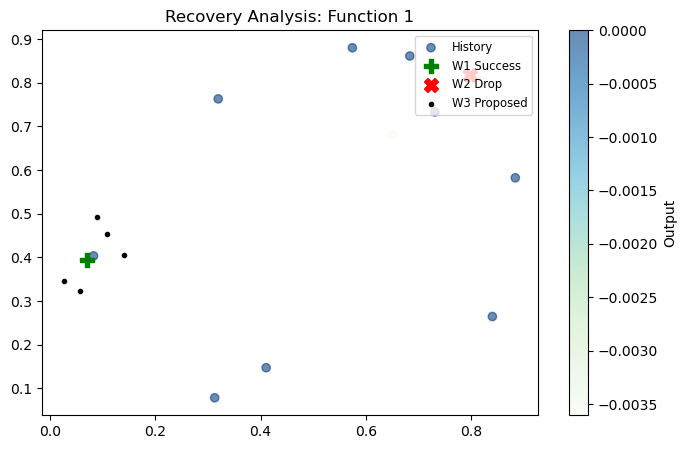


--- FUNCTION_1 RECOMMENDATIONS ---
Query 1: [0.1084,0.4528]
Query 2: [0.0271,0.3465]
Query 3: [0.09  ,0.4918]
Query 4: [0.0568,0.3223]
Query 5: [0.1412,0.4057]


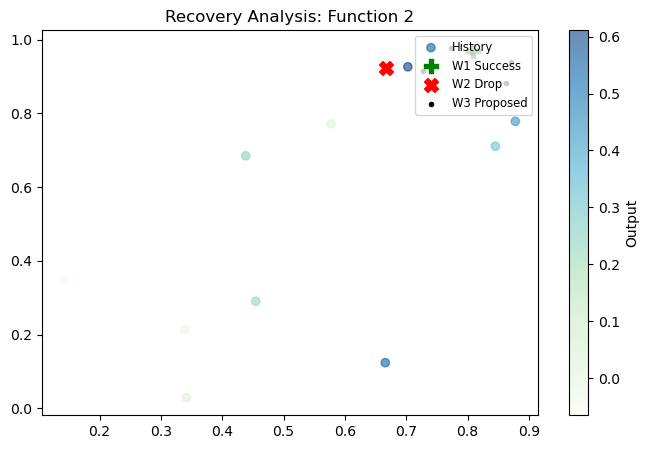


--- FUNCTION_2 RECOMMENDATIONS ---
Query 1: [0.8705,0.9385]
Query 2: [0.7737,0.9781]
Query 3: [0.7271,0.9159]
Query 4: [0.8634,0.8813]
Query 5: [0.8078,0.965 ]


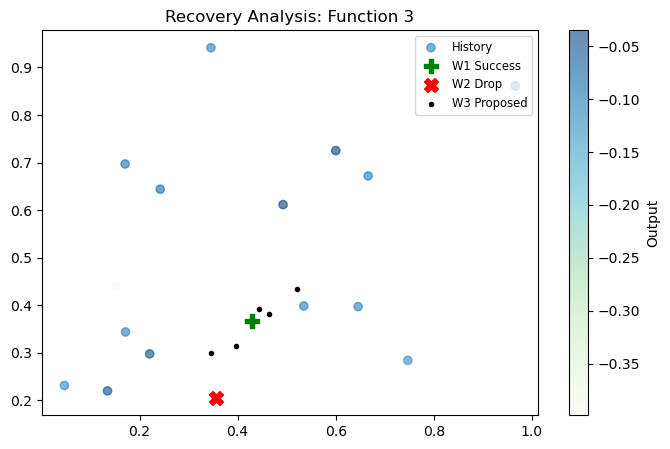


--- FUNCTION_3 RECOMMENDATIONS ---
Query 1: [0.4438,0.3911,0.5125]
Query 2: [0.4643,0.3813,0.4852]
Query 3: [0.5205,0.4342,0.5995]
Query 4: [0.3967,0.3143,0.4426]
Query 5: [0.3455,0.2995,0.5893]


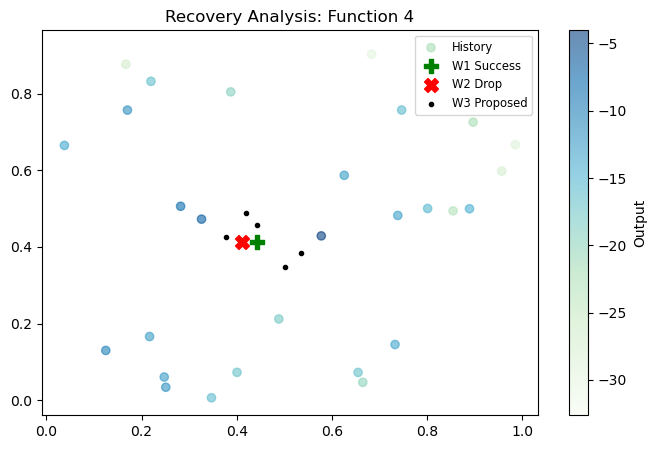


--- FUNCTION_4 RECOMMENDATIONS ---
Query 1: [0.442 ,0.458 ,0.285 ,0.4205]
Query 2: [0.5016,0.3483,0.4526,0.4892]
Query 3: [0.4194,0.4886,0.3852,0.5197]
Query 4: [0.5355,0.3844,0.3237,0.3846]
Query 5: [0.3782,0.4263,0.3965,0.369 ]


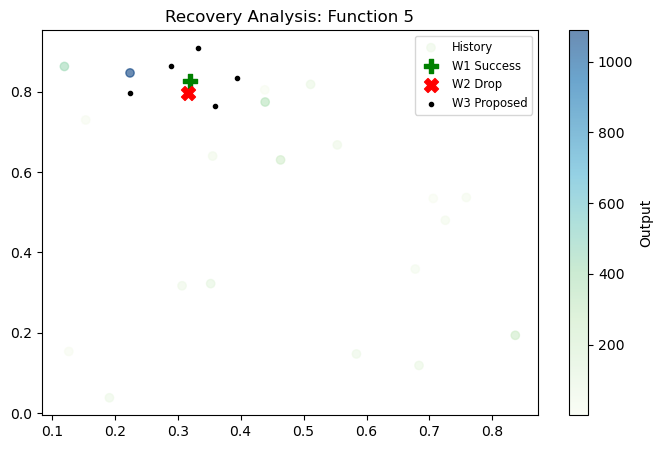


--- FUNCTION_5 RECOMMENDATIONS ---
Query 1: [0.3328,0.909 ,0.97  ,0.8494]
Query 2: [0.29  ,0.8648,0.9354,0.8192]
Query 3: [0.2243,0.7959,0.9833,0.9627]
Query 4: [0.3934,0.8326,0.948 ,0.9561]
Query 5: [0.3587,0.7652,0.9052,0.9018]


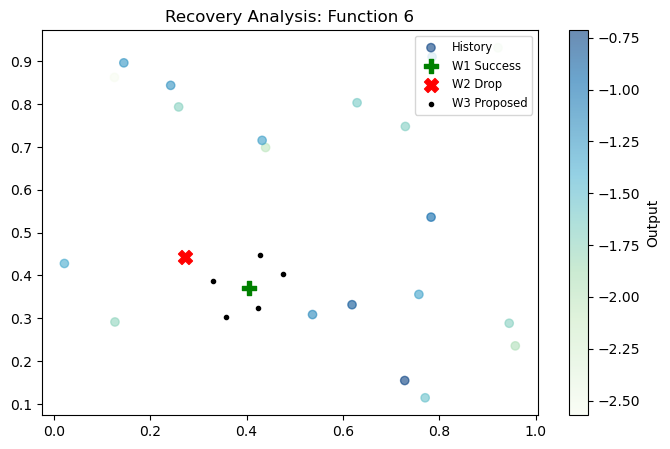


--- FUNCTION_6 RECOMMENDATIONS ---
Query 1: [0.3301,0.3866,0.4154,0.8303,0.0711]
Query 2: [0.3562,0.3025,0.5655,0.6489,0.1896]
Query 3: [0.4761,0.4025,0.4865,0.7721,0.0926]
Query 4: [0.4277,0.4476,0.4383,0.7143,0.2341]
Query 5: [0.4242,0.3249,0.5182,0.7401,0.1573]


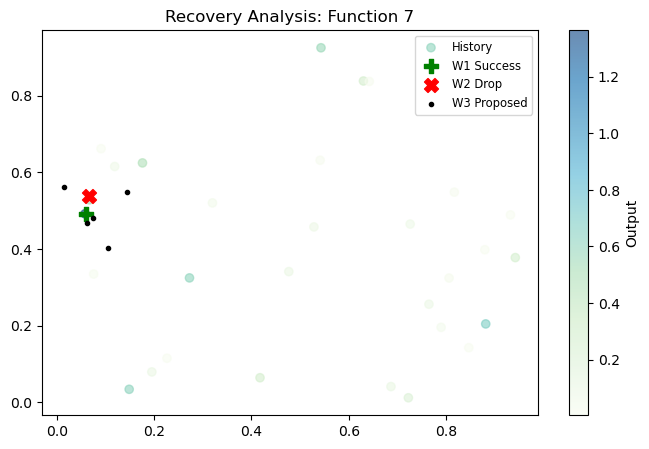


--- FUNCTION_7 RECOMMENDATIONS ---
Query 1: [0.1435,0.5492,0.2101,0.1239,0.4639,0.5763]
Query 2: [0.0748,0.4797,0.1512,0.0999,0.4392,0.7097]
Query 3: [0.0154,0.5611,0.282 ,0.2472,0.3941,0.6702]
Query 4: [0.0612,0.4671,0.0856,0.1826,0.3338,0.6365]
Query 5: [0.1048,0.4022,0.1847,0.1929,0.3177,0.6006]


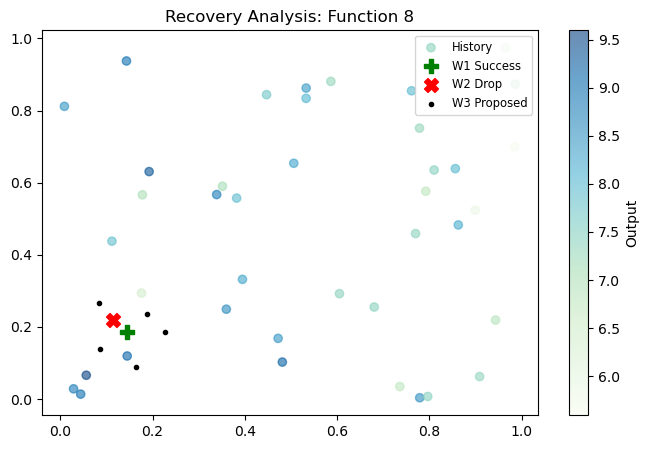


--- FUNCTION_8 RECOMMENDATIONS ---
Query 1: [0.0867,0.1378,0.0426,0.0578,0.8975,0.1569,0.0101,0.5623]
Query 2: [0.1634,0.0895,0.0733,0.1593,0.9376,0.2487,0.1151,0.4959]
Query 3: [0.1884,0.2368,0.1191,0.025 ,0.9993,0.3044,0.0598,0.4543]
Query 4: [0.2267,0.1868,0.1657,0.0858,0.9522,0.2143,0.1234,0.4195]
Query 5: [0.085 ,0.266 ,0.0036,0.1066,0.888 ,0.1968,0.0817,0.5906]


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.stats import qmc
import os

# Configuration
base_path = './capstone_data/initial_data/'
functions = [f'function_{i}' for i in range(1, 9)]
results_summary = {}

for func in functions:
    path = os.path.join(base_path, func)
    
    # 1. Load Data
    X = np.load(os.path.join(path, 'initial_inputs.npy'))
    y = np.load(os.path.join(path, 'initial_outputs.npy'))
    
    # Identify key performance markers
    x_w1, y_w1 = X[-2], y[-2]  # Week 1 Record
    x_w2, y_w2 = X[-1], y[-1]  # Week 2 Record
    best_idx = np.argmax(y)
    x_best, y_best = X[best_idx], y[best_idx]
    
    # 2. GP Modeling
    kernel = C(1.0) * Matern(length_scale=1.0, nu=2.5)
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5)
    gp.fit(X, y)
    
    # 3. LHS Recovery (Localized search around W1 success)
    sampler = qmc.LatinHypercube(d=X.shape[1])
    # Define recovery bounds: 10% window around Week 1 coordinates
    bounds_min = np.clip(x_w1 - 0.1, 0, 1)
    bounds_max = np.clip(x_w1 + 0.1, 0, 1)
    
    samples = sampler.random(n=5)
    next_queries = qmc.scale(samples, bounds_min, bounds_max)
    
    # Store recommendations
    results_summary[func] = next_queries
    
    # 4. Visualization (Following GnBu style)
    plt.figure(figsize=(8, 5))
    sc = plt.scatter(X[:-2, 0], X[:-2, 1], c=y[:-2], cmap='GnBu', alpha=0.6, label='History')
    plt.colorbar(sc, label='Output')
    
    # Contrast W1 and W2
    plt.scatter(x_w1[0], x_w1[1], c='green', marker='P', s=100, label='W1 Success')
    plt.scatter(x_w2[0], x_w2[1], c='red', marker='X', s=100, label='W2 Drop')
    plt.scatter(next_queries[:, 0], next_queries[:, 1], c='black', marker='.', label='W3 Proposed')
    
    plt.title(f"Recovery Analysis: {func.replace('_', ' ').title()}")
    plt.legend(loc='upper right', fontsize='small')
    plt.show()

    # Print summary for copying
    print(f"\n--- {func.upper()} RECOMMENDATIONS ---")
    for i, q in enumerate(next_queries):
        print(f"Query {i+1}: {np.array2string(q, precision=4, separator=',')}")

In [2]:
import numpy as np
import os
import warnings
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol

# Suppress ConvergenceWarnings for a cleaner output
warnings.filterwarnings("ignore", category=UserWarning)

# Configuration for all 8 functions
functions_config = [
    {'id': 1, 'dim': 2}, {'id': 2, 'dim': 2}, {'id': 3, 'dim': 3}, {'id': 4, 'dim': 4},
    {'id': 5, 'dim': 4}, {'id': 6, 'dim': 5}, {'id': 7, 'dim': 6}, {'id': 8, 'dim': 8}
]

def print_sobol_analysis():
    for config in functions_config:
        fn_num = config['id']
        dim = config['dim']
        
        # 1. Load the updated dataset (including Week 3)
        data_path = f'./capstone_data/initial_data/function_{fn_num}/'
        X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
        y = np.load(os.path.join(data_path, 'initial_outputs.npy'))
        
        # 2. Fit Gaussian Process with wider bounds for stability
        kernel = C(1.0, constant_value_bounds=(1e-7, 1e7)) * RBF(0.1, length_scale_bounds=(1e-4, 1e4))
        alpha_val = 0.05 if fn_num in [2, 7, 8] else 1e-6
        gp = GaussianProcessRegressor(kernel=kernel, alpha=alpha_val, n_restarts_optimizer=10)
        gp.fit(X, y)
        
        # 3. Define Sobol Problem
        problem = {
            'num_vars': dim,
            'names': [f'x{i+1}' for i in range(dim)],
            'bounds': [[0, 1]] * dim
        }
        
        # 4. Generate Samples and Predict
        param_values = sobol_sample.sample(problem, 1024)
        y_pred = gp.predict(param_values)
        Si = sobol.analyze(problem, y_pred)
        
        # 5. Print Results in a simple list
        print(f"\n--- Function {fn_num} ({dim}D) Sobol Indices ---")
        for i, name in enumerate(problem['names']):
            print(f"  {name}: {Si['S1'][i]:.4f}")

# Execute the analysis
print_sobol_analysis()


--- Function 1 (2D) Sobol Indices ---
  x1: 0.1782
  x2: 0.2103

--- Function 2 (2D) Sobol Indices ---
  x1: 0.8213
  x2: 0.1742

--- Function 3 (3D) Sobol Indices ---
  x1: 0.2577
  x2: 0.0257
  x3: 0.1030

--- Function 4 (4D) Sobol Indices ---
  x1: 0.2343
  x2: 0.2638
  x3: 0.2025
  x4: 0.2244

--- Function 5 (4D) Sobol Indices ---
  x1: 0.0658
  x2: 0.0201
  x3: 0.0869
  x4: 0.1039

--- Function 6 (5D) Sobol Indices ---
  x1: 0.1985
  x2: 0.1026
  x3: 0.1258
  x4: 0.3008
  x5: 0.0556

--- Function 7 (6D) Sobol Indices ---
  x1: 0.1491
  x2: 0.0231
  x3: 0.0423
  x4: 0.1431
  x5: 0.1691
  x6: 0.0869

--- Function 8 (8D) Sobol Indices ---
  x1: 0.2495
  x2: 0.0371
  x3: 0.5270
  x4: 0.0234
  x5: 0.0041
  x6: 0.0030
  x7: 0.1457
  x8: 0.0063
